### Load libraries and dataset

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(X_train, Y_train), (X_test, Y_test) = datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
Y_train.shape

(50000, 1)

In [6]:
Y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [7]:
Y_train = Y_train.reshape(-1,)
Y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [8]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

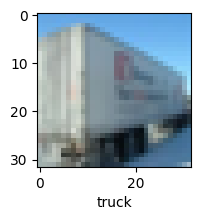

In [9]:
def plt_sample(X, Y, index):
    plt.figure(figsize=(15, 2))
    plt.imshow(X[index])
    plt.xlabel(classes[Y[index]])

plt_sample(X_train, Y_train, 15)

In [10]:
X_train = X_train[0]/225
X_test = X_test[0]/225

### CNN model

In [11]:
cnn = models.Sequential([
    #CNN
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Dense
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [14]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np

# Re-load data to undo the incorrect slicing from a previous cell
# This assumes the original data loading was in (X_train, Y_train), (X_test, Y_test)
(X_train_full, Y_train_full), (X_test_full, Y_test_full) = datasets.cifar10.load_data()

# Normalize X_train_full and X_test_full correctly
X_train_normalized = X_train_full / 255.0
X_test_normalized = X_test_full / 255.0

# Reshape Y_train_full as it was done previously
Y_train_reshaped = Y_train_full.reshape(-1,)

# Now call fit with the correctly shaped and normalized data
cnn.fit(X_train_normalized, Y_train_reshaped, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.4651 - loss: 1.4822
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 43ms/step - accuracy: 0.5990 - loss: 1.1412
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6471 - loss: 1.0090
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6769 - loss: 0.9286
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.6986 - loss: 0.8632
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7190 - loss: 0.8086
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7351 - loss: 0.7610
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.7490 - loss: 0.7192
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7632 - loss: 0.6778
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 42ms/step - accuracy: 0.7760 - loss: 0.6397


In [16]:
cnn.evaluate(X_test_normalized, Y_test_full.reshape(-1,))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6882 - loss: 0.9509


[0.9508705139160156, 0.6881999969482422]

### Các kỹ thuật cải thiện mô hình CNN

Bạn có thể thử các thay đổi sau để nâng cao độ chính xác:
* **Thêm Dropout**: Để giảm overfitting.
* **Batch Normalization**: Giúp mô hình hội tụ nhanh hơn.
* **Tăng số lượng filters**: Ví dụ: 32 -> 64 -> 128.
* **Sử dụng Data Augmentation**: Để làm phong phú tập dữ liệu huấn luyện.

In [ ]:
# Ví dụ về mô hình CNN cải tiến hơn
improved_cnn = models.Sequential([
    # Khối 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Khối 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Dense
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

improved_cnn.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

improved_cnn.summary()